In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv(r'C:\Users\Omen\Desktop\The Data Foundation Medical Insights & EDA\data\heart.csv')
print(df.head())



   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [3]:
print(df.isnull().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [4]:
for col in df.select_dtypes(include = ['object']):
    df[col] = df[col].str.strip()

print("data cleaning has been completed")    

data cleaning has been completed


In [5]:
print(df.describe())
print(df.shape)


               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    71.000000  

The dataset was examined. It was observed that it contains a total of 1025 rows and 14 columns. No missing data was found / missing values were cleaned. Data types were adjusted to be suitable for analysis.

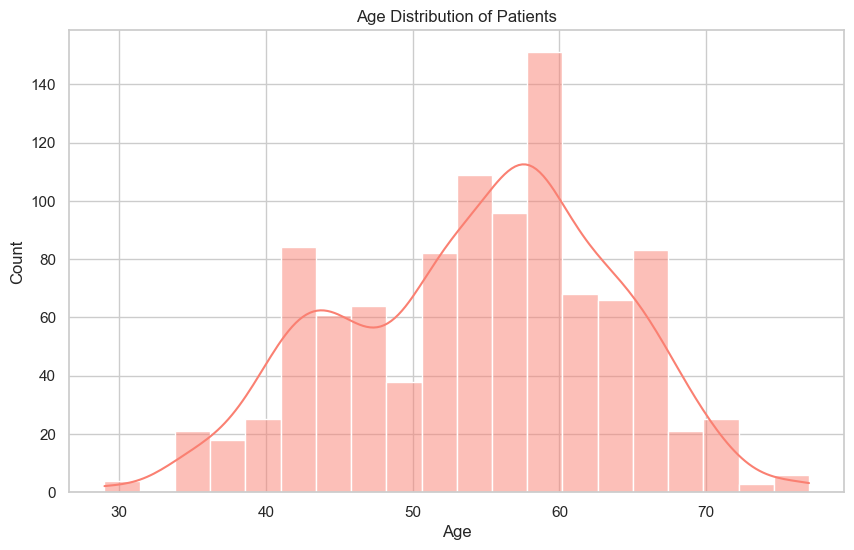

In [6]:

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
sns.histplot(df['age'], bins=20, kde=True, color='salmon')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

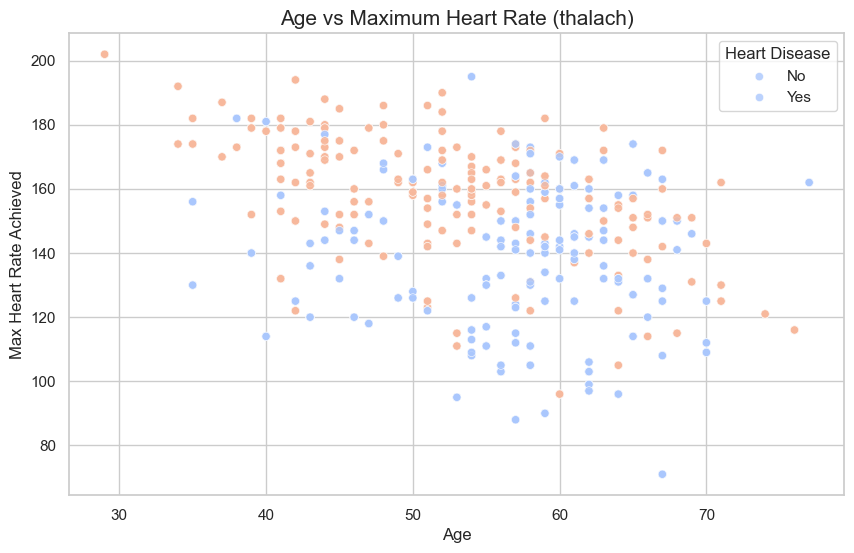

In [7]:
plt.figure()
sns.scatterplot(x='age', y='thalach', data=df, hue='target', palette='coolwarm', alpha=0.8)
plt.title('Age vs Maximum Heart Rate (thalach)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Max Heart Rate Achieved', fontsize=12)
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.show()

#yaş ilerledikçe maksimum kalp atış hızındaki değişim

C:\Users\Omen\AppData\Local\Temp\ipykernel_34376\1362395376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='chol', data=df, palette='Set2')


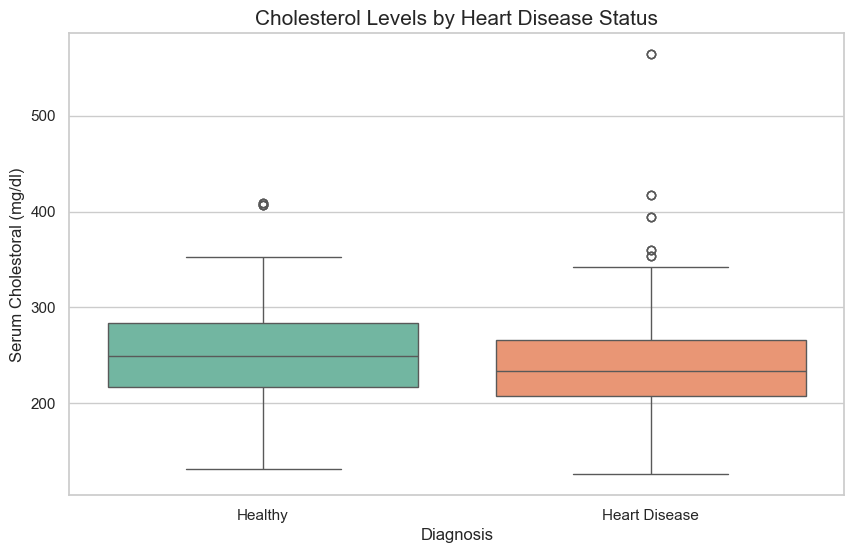

In [12]:
plt.figure()
sns.boxplot(x='target', y='chol', data=df, palette='Set2')
plt.title('Cholesterol Levels by Heart Disease Status', fontsize=15)
plt.xticks([0, 1], ['Healthy', 'Heart Disease'])
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Serum Cholestoral (mg/dl)', fontsize=12)
plt.show()

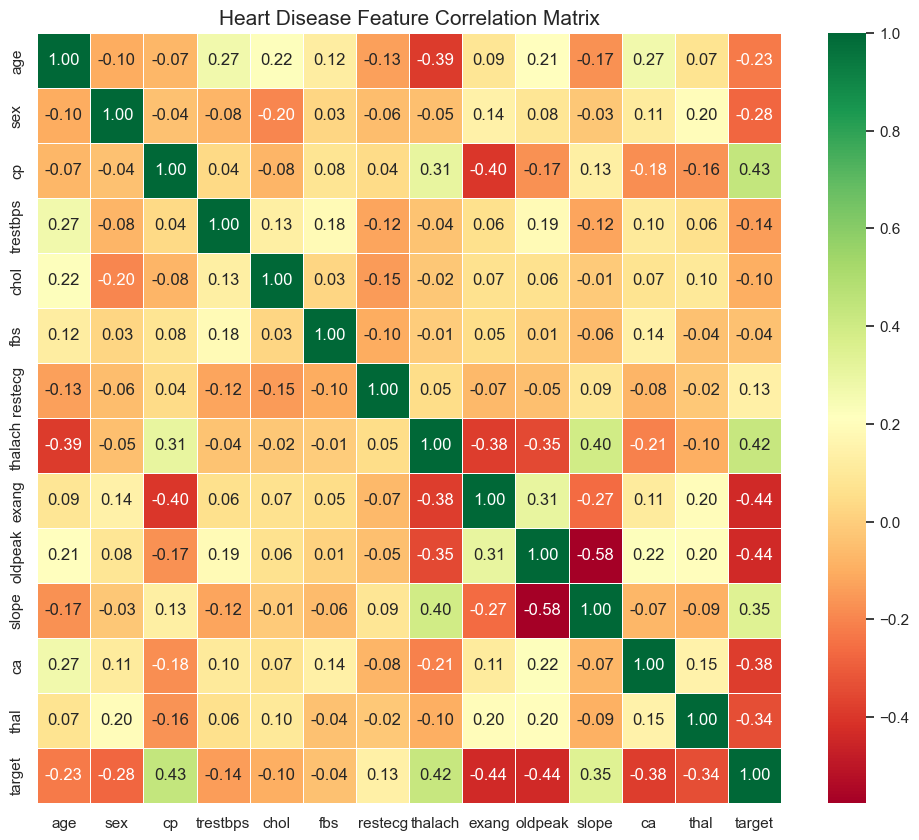

In [9]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Heart Disease Feature Correlation Matrix', fontsize=15)
plt.show()

Encoding and statistical summ

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


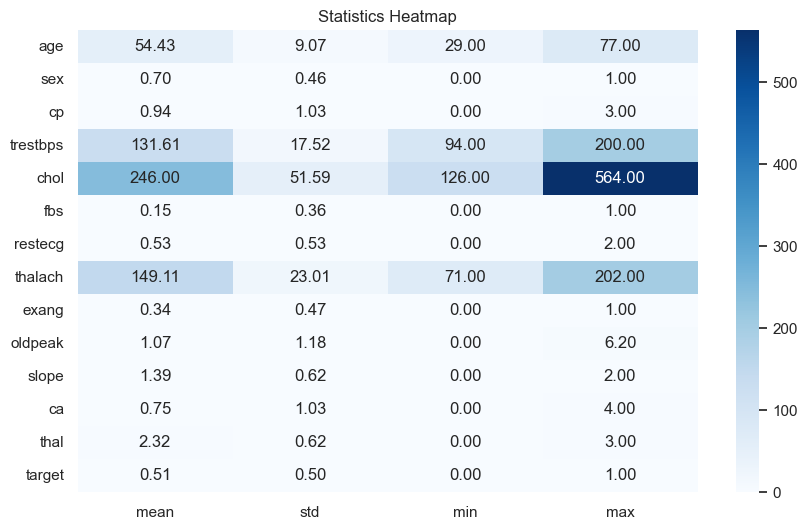

In [10]:
print(df.dtypes)
stats_summary = df.describe().T
plt.figure(figsize=(10, 6))
sns.heatmap(df.describe().T[['mean', 'std', 'min', 'max']], annot=True, cmap='Blues', fmt='.2f')
plt.title('Statistics Heatmap')
plt.show()
#standart sapmaya bakmak önemli 

Feature Scaling- Preparation for linear engine

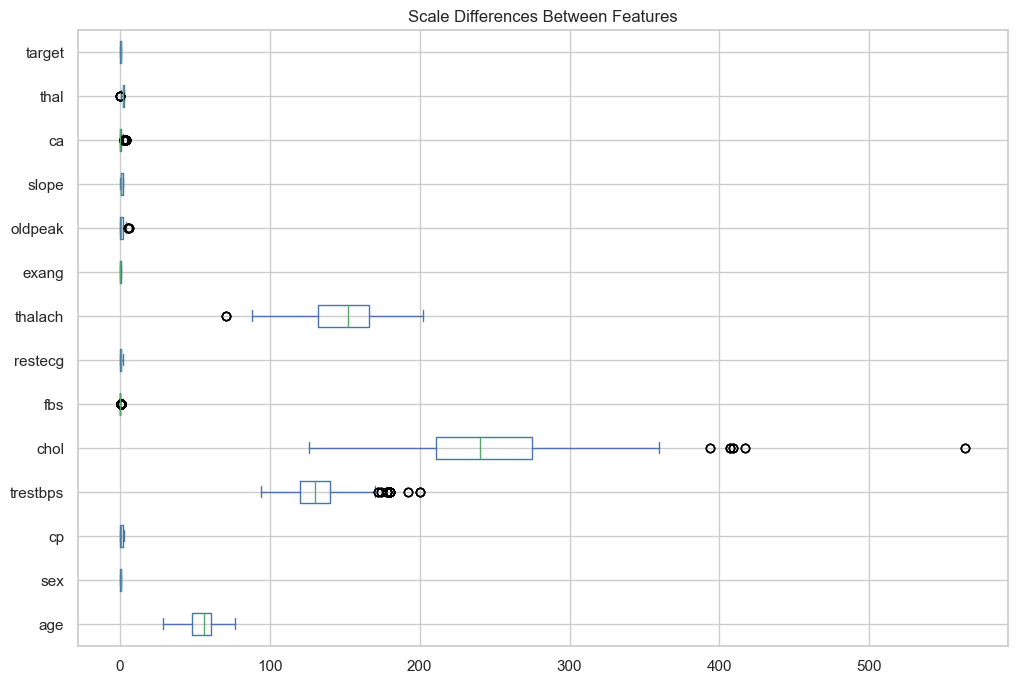

In [11]:
df.plot(kind='box', vert=False, figsize=(12,8))
plt.title('Scale Differences Between Features')
plt.show()

Conclusion And Next Steps
we have:

1.Cleaned and validated the Heart Disease dataset.

2.Discovered key correlations between age, heart rate, and disease risk.

3.Prepared the data for mathematical modeling.

The foundation is solid. We are now ready to ignite The Linear Engine and start predicting heart disease using Linear/Logistic Regression.
